<a href="https://colab.research.google.com/github/sabiha311/COMP-ANALY-HIGH-TP-BIOMED-DATA/blob/main/final_project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scanpy anndata matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 58.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving GSE185068_RAW.tar to GSE185068_RAW.tar


In [ ]:
import tarfile

tar = tarfile.open("GSE185068_RAW.tar")
tar.extractall("GSE185068_RAW")
tar.close()


In [ ]:
import pandas as pd
import scanpy as sc

# Load S1-1
counts_s1 = pd.read_csv("GSE185068_RAW/GSM5605641_S1-1.counts.tsv.gz", sep="\t", index_col=0)
cells_s1 = pd.read_csv("GSE185068_RAW/GSM5605641_S1-1.cellname.list.txt.gz", sep="\t", header=None)[0]
cells_s1 = cells_s1.dropna().astype(str).str.strip().iloc[:counts_s1.shape[1]]
counts_s1.columns = cells_s1
adata_s1 = sc.AnnData(counts_s1.T)
adata_s1.obs["sample"] = "S1"

# Load S2-1
counts_s2 = pd.read_csv("GSE185068_RAW/GSM5605643_S2-1.counts.tsv.gz", sep="\t", index_col=0)
cells_s2 = pd.read_csv("GSE185068_RAW/GSM5605643_S2-1.cellname.list.txt.gz", sep="\t", header=None)[0]
cells_s2 = cells_s2.dropna().astype(str).str.strip().iloc[:counts_s2.shape[1]]
counts_s2.columns = cells_s2
adata_s2 = sc.AnnData(counts_s2.T)
adata_s2.obs["sample"] = "S2"


In [ ]:
import anndata as ad

adata = ad.concat([adata_s1, adata_s2], label="sample", keys=["S1", "S2"], merge="same")


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.0 MB/s eta 0:00:00


<ipython-input-6-31b929bf1a0b>:12: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


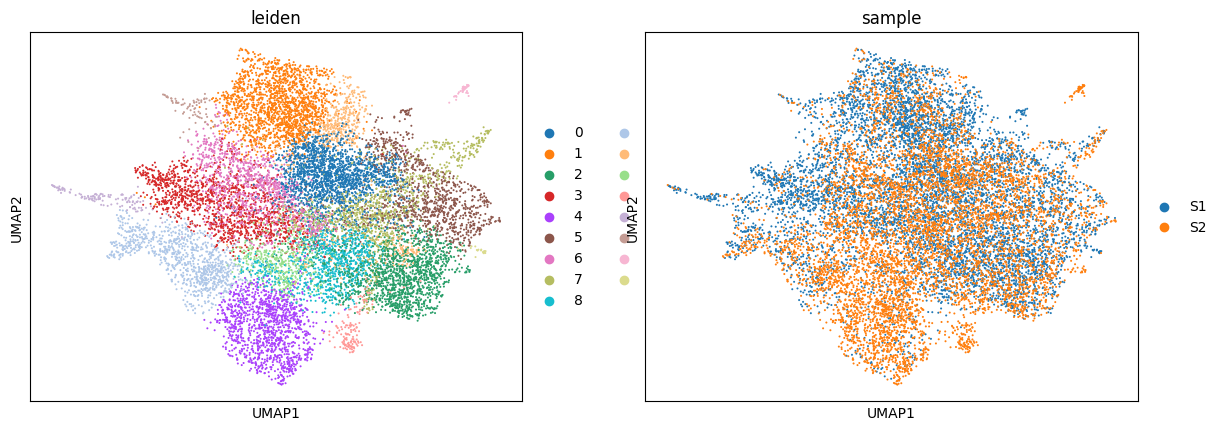

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Install Leiden backend
!pip install igraph leidenalg

sc.tl.leiden(adata)

# View clusters
sc.pl.umap(adata, color=["leiden", "sample"])


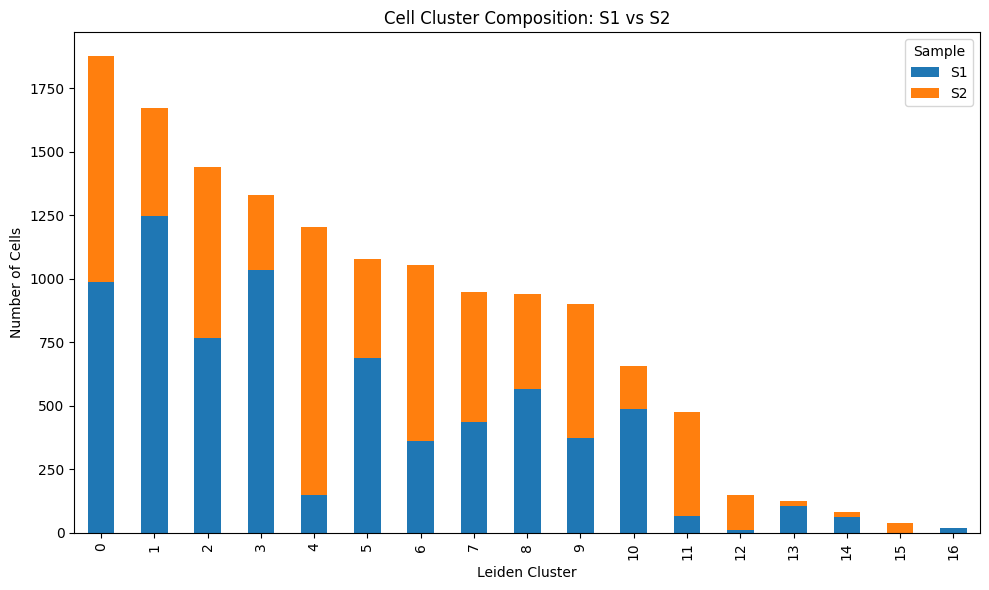

In [ ]:
# Count cells per cluster by sample
import matplotlib.pyplot as plt

cluster_counts = pd.crosstab(adata.obs["leiden"], adata.obs["sample"])
cluster_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Cell Cluster Composition: S1 vs S2")
plt.xlabel("Leiden Cluster")
plt.ylabel("Number of Cells")
plt.legend(title="Sample")
plt.tight_layout()
plt.show()
